## Load cached evaluation scores

Load pre-computed scores from `eval_scores.json` (created by `eval_dataset_creation.ipynb`).
To re-run the RAG pipeline and scoring from scratch, use the dataset creation notebook instead.

In [1]:
import numpy as np
from bayesAB.config import global_config as glob
from bayesAB.services.file import JSONService

scores_svc = JSONService(path="eval_scores.json", root_path=glob.DATA_PKG_DIR, verbose=True)
cached = scores_svc.doRead()

metric_names = list(cached['metrics'].keys())

print(f"Loaded scores from {scores_svc.path}")
print(f"  Models: {cached['model_A']} vs {cached['model_B']}")
print(f"  Timestamp: {cached['timestamp']}")
print(f"  Items: {cached['n_items']}")
print(f"  Metrics: {metric_names}")

for metric in metric_names:
    m = cached['metrics'][metric]
    s_A = np.array(m['s_A_raw'])
    s_B = np.array(m['s_B_raw'])
    print(f"  {metric}: n_A={len(s_A)}, n_B={len(s_B)}, mean_A={s_A.mean():.3f}, mean_B={s_B.mean():.3f}")

Read: /Users/avosseler/Github_priv/bayesAB/data/eval_scores.json
Loaded scores from /Users/avosseler/Github_priv/bayesAB/data/eval_scores.json
  Models: gemini-2.5-flash vs gemini-2.0-flash
  Timestamp: 2026-05-04T00:34:40.832923
  Items: 100
  Metrics: ['Answer Relevancy', 'Faithfulness']
  Answer Relevancy: n_A=100, n_B=100, mean_A=0.975, mean_B=0.980
  Faithfulness: n_A=100, n_B=100, mean_A=0.985, mean_B=0.959


## Paired Model Comparison using Pooled Bayesian Logistic Regression (Binomial)

Compare Model A vs Model B on different LLM metrics using a **pooled Bernoulli logistic model**.

### Motivation

Evaluation scores from metrics like Answer Relevancy and Faithfulness are heavily concentrated
at the boundary (>90% of scores are exactly 1.0). We **binarize** each score as
$y_i = \mathbb{1}[s_i = 1]$ (perfect vs imperfect) and fit a pooled logistic regression.

The hierarchical model (per-item $\theta_i$) confounds with $\delta_A$ when >90% of pairs
are concordant (both perfect), causing PPC misfit. The pooled model avoids this by estimating
only two parameters.

### Model

$$
\mu \sim N(0, 2) \quad \text{(overall intercept)}
$$
$$
\delta_A \sim N(0, \sigma_s) \quad \text{(model A advantage — fixed prior width for Savage-Dickey)}
$$
$$
y_{A,i} \sim \text{Bernoulli}\bigl(\sigma(\mu + \delta_A)\bigr), \quad
y_{B,i} \sim \text{Bernoulli}\bigl(\sigma(\mu)\bigr)
$$

### Advantages

- **Only 2 parameters** — no confounding between item effects and model effect
- **Trivial PPC** — simulate Bernoulli draws, compare fraction of 1s
- **Savage-Dickey** works identically (same fixed prior on $\delta_A$)
- **Clear interpretation**: does model A achieve perfect scores more often?

In [2]:
from bayesAB.resources.bayes_paired_laplace import PairedBayesPropTest
from bayesAB.utils.utils import simulate_paired_scores

# ── Simulate data (logistic DGP, no random effects) ──────────────────
sim = simulate_paired_scores(N=150, delta_A=0.8, sigma_theta=0.0, seed=42)

print(f"True δ_A = {sim['true_params']['delta_A']}")
print(f"Observed rates: A = {sim['y_A'].mean():.3f},  B = {sim['y_B'].mean():.3f}")

# ── Fit model ────────────────────────────────────────────────────────
model_sim = PairedBayesPropTest(seed=42, n_samples=50_000).fit(sim["y_A"], sim["y_B"])

s = model_sim.summary
print(f"\nδ_A posterior mean = {s.delta_A_posterior_mean:+.4f}")
print(f"Mean Δ (prob)  = {s.mean_delta:+.4f}")
print(f"95% CI         = [{s.ci_95.lower:.4f}, {s.ci_95.upper:.4f}]")
print(f"P(A>B)         = {s.p_A_greater_B:.4f}")

bf_sim = model_sim.savage_dickey_test()
print(f"\nBF₁₀ = {bf_sim.BF_10:.2f}  → {bf_sim.decision}")

True δ_A = 0.8
Observed rates: A = 0.680,  B = 0.547

δ_A posterior mean = +0.5355
Mean Δ (prob)  = +0.1253
95% CI         = [0.0192, 0.2306]
P(A>B)         = 0.9901

BF₁₀ = 3.35  → Reject H0


In [3]:
from bayesAB.resources.bayes_paired_laplace import PairedBayesPropTest, sigmoid, _format_bf

In [4]:
import numpy as np
import matplotlib.pyplot as plt

BINARIZE_THRESHOLD = 0.7  # perfect score vs imperfect

print("Pooled Bernoulli Logistic Regression (Laplace): Gemini 2.5 Flash vs Gemini 2.0 Flash")
print("=" * 70)

comparison_results = {}

for metric in metric_names:
    m = cached['metrics'][metric]
    s_A = np.array(m['s_A_raw'])
    s_B = np.array(m['s_B_raw'])

    n = min(len(s_A), len(s_B))
    s_A = s_A[:n]
    s_B = s_B[:n]

    # Binarize: 1 if score >= threshold, 0 otherwise
    y_A = (s_A >= BINARIZE_THRESHOLD).astype(int)
    y_B = (s_B >= BINARIZE_THRESHOLD).astype(int)

    print(f"\n{metric} (n={n}):")
    print(f"  Raw score range: A=[{s_A.min():.3f}, {s_A.max():.3f}], B=[{s_B.min():.3f}, {s_B.max():.3f}]")
    print(f"  Binarized y=1 (perfect): A={y_A.mean():.1%} ({y_A.sum()}/{n}), B={y_B.mean():.1%} ({y_B.sum()}/{n})")
    print(f"  Observed difference in rates: {y_A.mean() - y_B.mean():.4f}")

    model = PairedBayesPropTest(seed=42).fit(y_A, y_B)

    comparison_results[metric] = {
        'model': model,
        's_A_raw': s_A,
        's_B_raw': s_B,
    }

    s = model.summary
    print(f"  Mean Δ (prob scale): {s.mean_delta:.4f}")
    print(f"  95% CI: [{s.ci_95.lower:.4f}, {s.ci_95.upper:.4f}]")
    print(f"  P(2.5-Flash > 2.0-Flash): {s.p_A_greater_B:.4f}")
    print(f"  δ_A (logit scale): {s.delta_A_posterior_mean:.4f}")

Pooled Bernoulli Logistic Regression (Laplace): Gemini 2.5 Flash vs Gemini 2.0 Flash

Answer Relevancy (n=100):
  Raw score range: A=[0.400, 1.000], B=[0.000, 1.000]
  Binarized y=1 (perfect): A=96.0% (96/100), B=99.0% (99/100)
  Observed difference in rates: -0.0300
  Mean Δ (prob scale): -0.0132
  95% CI: [-0.0632, 0.0280]
  P(2.5-Flash > 2.0-Flash): 0.2469
  δ_A (logit scale): -0.4370

Faithfulness (n=100):
  Raw score range: A=[0.500, 1.000], B=[0.000, 1.000]
  Binarized y=1 (perfect): A=98.0% (98/100), B=93.0% (93/100)
  Observed difference in rates: 0.0500
  Mean Δ (prob scale): 0.0383
  95% CI: [-0.0129, 0.0993]
  P(2.5-Flash > 2.0-Flash): 0.9365
  δ_A (logit scale): 0.8824



  Laplace posterior: Answer Relevancy
  MAP: μ=3.7233, δ_A=-0.4277
  Posterior sd: μ=0.5482, δ_A=0.6368
  Correlation: -0.667


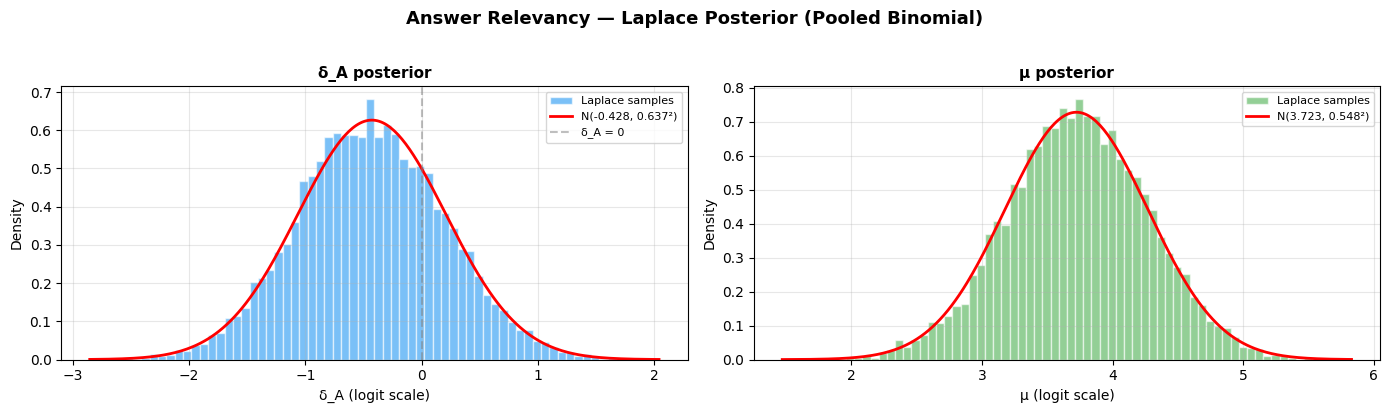

,mean,sd,hdi_3%,hdi_97%,MAP
delta_A,-0.437027,0.633896,-1.624608,0.758662,-0.427691
mu,3.728788,0.540450,2.689056,4.738477,3.723273



  Laplace posterior: Faithfulness
  MAP: μ=2.6234, δ_A=0.8909
  Posterior sd: μ=0.3703, δ_A=0.5807
  Correlation: -0.470


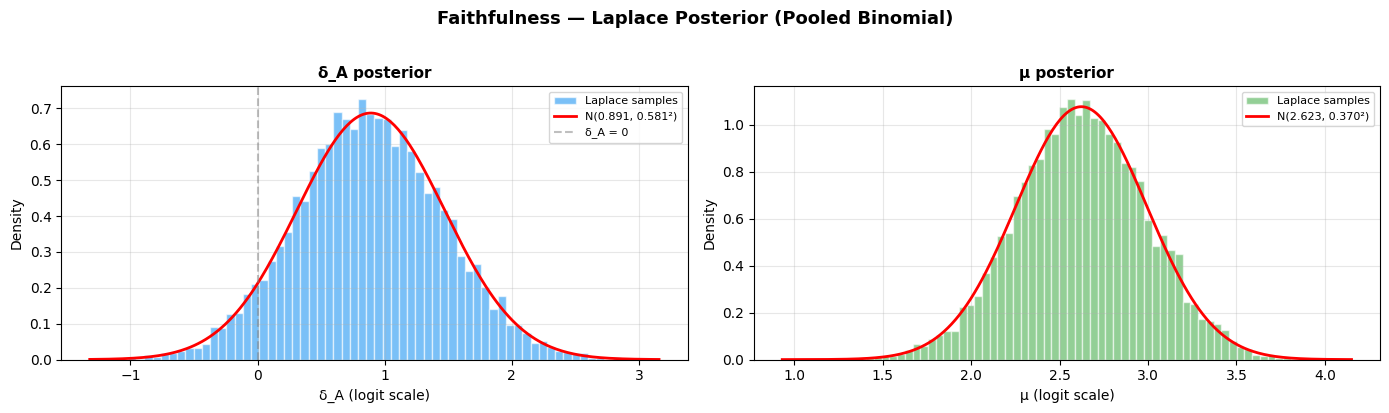

,mean,sd,hdi_3%,hdi_97%,MAP
delta_A,0.882429,0.575431,-0.201108,1.971229,0.890897
mu,2.625398,0.369212,1.932775,3.327281,2.623370


In [5]:
import matplotlib.pyplot as plt
from scipy.stats import norm

for metric, res in comparison_results.items():
    model = res['model']
    laplace = model.laplace
    mu_s = laplace['mu_samples']
    delta_s = laplace['delta_A_samples']
    mu_map, delta_map = laplace['map']
    cov = laplace['cov']

    print(f"\n{'='*60}")
    print(f"  Laplace posterior: {metric}")
    print(f"  MAP: μ={mu_map:.4f}, δ_A={delta_map:.4f}")
    print(f"  Posterior sd: μ={np.sqrt(cov[0,0]):.4f}, δ_A={np.sqrt(cov[1,1]):.4f}")
    print(f"  Correlation: {cov[0,1]/np.sqrt(cov[0,0]*cov[1,1]):.3f}")
    print(f"{'='*60}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # δ_A
    ax = axes[0]
    ax.hist(delta_s, bins=60, density=True, alpha=0.6, color='#2196F3', edgecolor='white', label='Laplace samples')
    x = np.linspace(delta_s.min() - 0.3, delta_s.max() + 0.3, 300)
    sd_d = np.sqrt(cov[1, 1])
    ax.plot(x, norm.pdf(x, delta_map, sd_d), 'r-', lw=2, label=f'N({delta_map:.3f}, {sd_d:.3f}²)')
    ax.axvline(0, color='gray', ls='--', alpha=0.5, label='δ_A = 0')
    ax.set_xlabel('δ_A (logit scale)')
    ax.set_ylabel('Density')
    ax.set_title(f'δ_A posterior', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # μ
    ax = axes[1]
    ax.hist(mu_s, bins=60, density=True, alpha=0.6, color='#4CAF50', edgecolor='white', label='Laplace samples')
    x_mu = np.linspace(mu_s.min() - 0.3, mu_s.max() + 0.3, 300)
    sd_m = np.sqrt(cov[0, 0])
    ax.plot(x_mu, norm.pdf(x_mu, mu_map, sd_m), 'r-', lw=2, label=f'N({mu_map:.3f}, {sd_m:.3f}²)')
    ax.set_xlabel('μ (logit scale)')
    ax.set_ylabel('Density')
    ax.set_title(f'μ posterior', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    fig.suptitle(f'{metric} — Laplace Posterior (Pooled Binomial)', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    metric_slug = metric.lower().replace(' ', '_')
    fig.savefig(f"../../docs/trace_plot_binomial_{metric_slug}.png", dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()

    display(model.trace_summary)

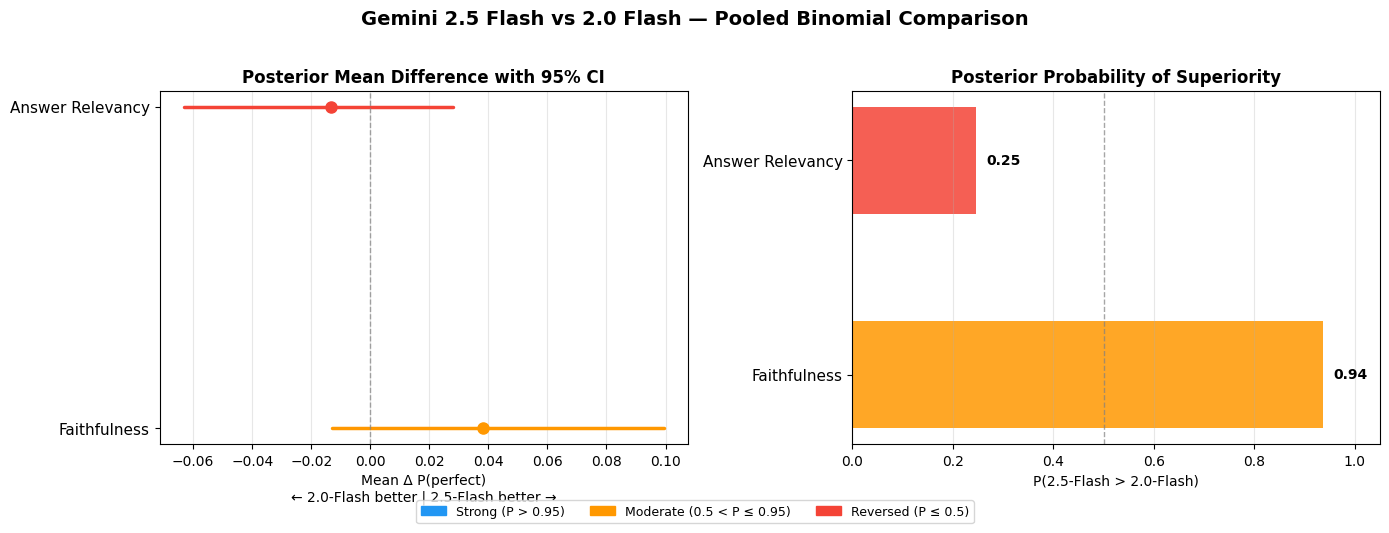

Metric                      Mean Δ               95% CI   P(A>B)      Verdict
Answer Relevancy           -0.0132 [-0.0632,  0.0280]   0.2469       B wins
Faithfulness                0.0383 [-0.0129,  0.0993]   0.9365         Tied


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

models = {m: res['model'] for m, res in comparison_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = list(models.keys())
means = [models[m].summary.mean_delta for m in metrics]
ci_lows = [models[m].summary.ci_95.lower for m in metrics]
ci_highs = [models[m].summary.ci_95.upper for m in metrics]
probs = [models[m].summary.p_A_greater_B for m in metrics]

colors = ['#2196F3' if p > 0.95 else '#FF9800' if p > 0.5 else '#F44336' for p in probs]
y_pos = np.arange(len(metrics))

ax = axes[0]
for i, (m, ci_l, ci_h, col) in enumerate(zip(means, ci_lows, ci_highs, colors)):
    ax.plot([ci_l, ci_h], [i, i], color=col, linewidth=2.5, solid_capstyle='round')
    ax.plot(m, i, 'o', color=col, markersize=8, zorder=5)

ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(metrics, fontsize=11)
ax.set_xlabel('Mean Δ P(perfect)\n← 2.0-Flash better | 2.5-Flash better →', fontsize=10)
ax.set_title('Posterior Mean Difference with 95% CI', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

ax2 = axes[1]
ax2.barh(y_pos, probs, color=colors, height=0.5, alpha=0.85)
ax2.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(metrics, fontsize=11)
ax2.set_xlabel('P(2.5-Flash > 2.0-Flash)', fontsize=10)
ax2.set_title('Posterior Probability of Superiority', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 1.05)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

for i, p in enumerate(probs):
    ax2.text(p + 0.02, i, f'{p:.2f}', va='center', fontsize=10, fontweight='bold')

legend_elements = [
    mpatches.Patch(color='#2196F3', label='Strong (P > 0.95)'),
    mpatches.Patch(color='#FF9800', label='Moderate (0.5 < P ≤ 0.95)'),
    mpatches.Patch(color='#F44336', label='Reversed (P ≤ 0.5)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Gemini 2.5 Flash vs 2.0 Flash — Pooled Binomial Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig("../../docs/forest_plot_binomial.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

PairedBayesPropTest.print_comparison_table(models)

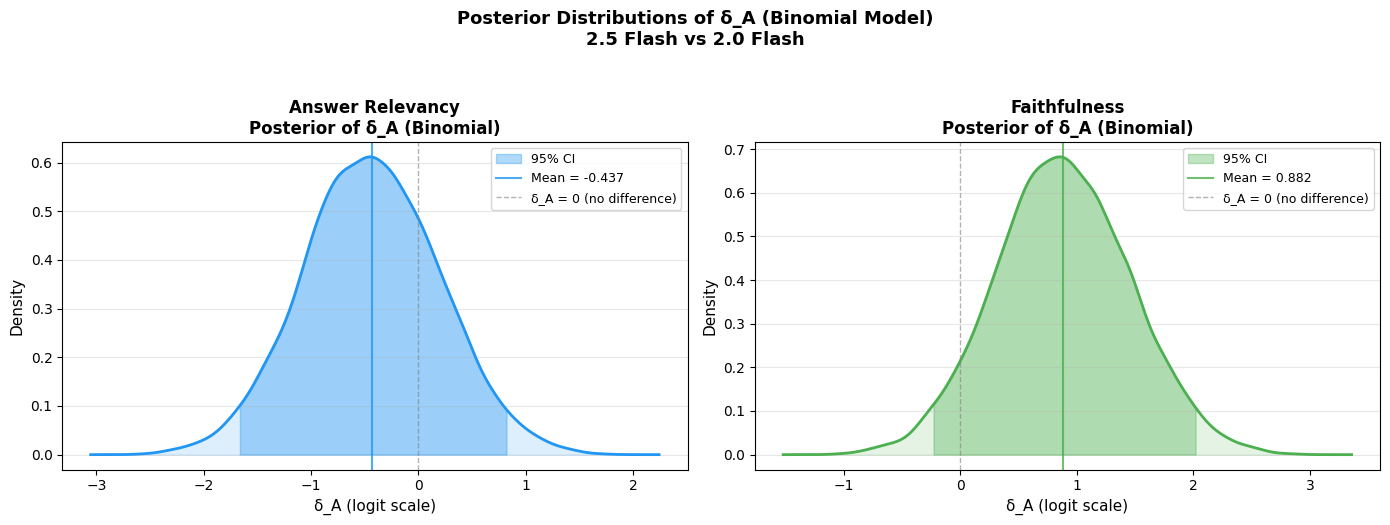

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, len(comparison_results), figsize=(7 * len(comparison_results), 5), squeeze=False)
axes = axes[0]

colors = {'Answer Relevancy': '#2196F3', 'Faithfulness': '#4CAF50'}

for ax, (metric, res) in zip(axes, comparison_results.items()):
    model = res['model']
    samples = model.delta_A_samples
    ci_low, ci_high = np.quantile(samples, [0.025, 0.975])
    mean_val = samples.mean()

    kde = gaussian_kde(samples)
    x_grid = np.linspace(samples.min() - 0.5, samples.max() + 0.5, 500)
    density = kde(x_grid)

    col = colors.get(metric, '#2196F3')
    ax.plot(x_grid, density, color=col, linewidth=2)
    ax.fill_between(x_grid, density, alpha=0.15, color=col)

    mask = (x_grid >= ci_low) & (x_grid <= ci_high)
    ax.fill_between(x_grid[mask], density[mask], alpha=0.35, color=col, label='95% CI')

    ax.axvline(mean_val, color=col, linestyle='-', linewidth=1.5, alpha=0.8, label=f'Mean = {mean_val:.3f}')
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='δ_A = 0 (no difference)')

    ax.set_xlabel('δ_A (logit scale)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{metric}\nPosterior of δ_A (Binomial)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Posterior Distributions of δ_A (Binomial Model)\n2.5 Flash vs 2.0 Flash',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
fig.savefig("../../docs/posterior_delta_A_binomial.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Posterior Predictive Check (PPC) — Binomial Model

For binary data, PPC is straightforward:
1. For each posterior draw, compute $p_{A,i} = \sigma(\theta_i + \delta_A)$ and $p_{B,i} = \sigma(\theta_i)$
2. Draw $y^{\text{rep}}_{A,i} \sim \text{Bernoulli}(p_{A,i})$ and $y^{\text{rep}}_{B,i} \sim \text{Bernoulli}(p_{B,i})$
3. Compare replicated statistics (fraction of 1s, pairwise differences) to observed data

Since the likelihood is exactly Bernoulli, the PPC should calibrate well — the model cannot "misfit" in the same way the Beta model did with boundary-concentrated continuous scores.

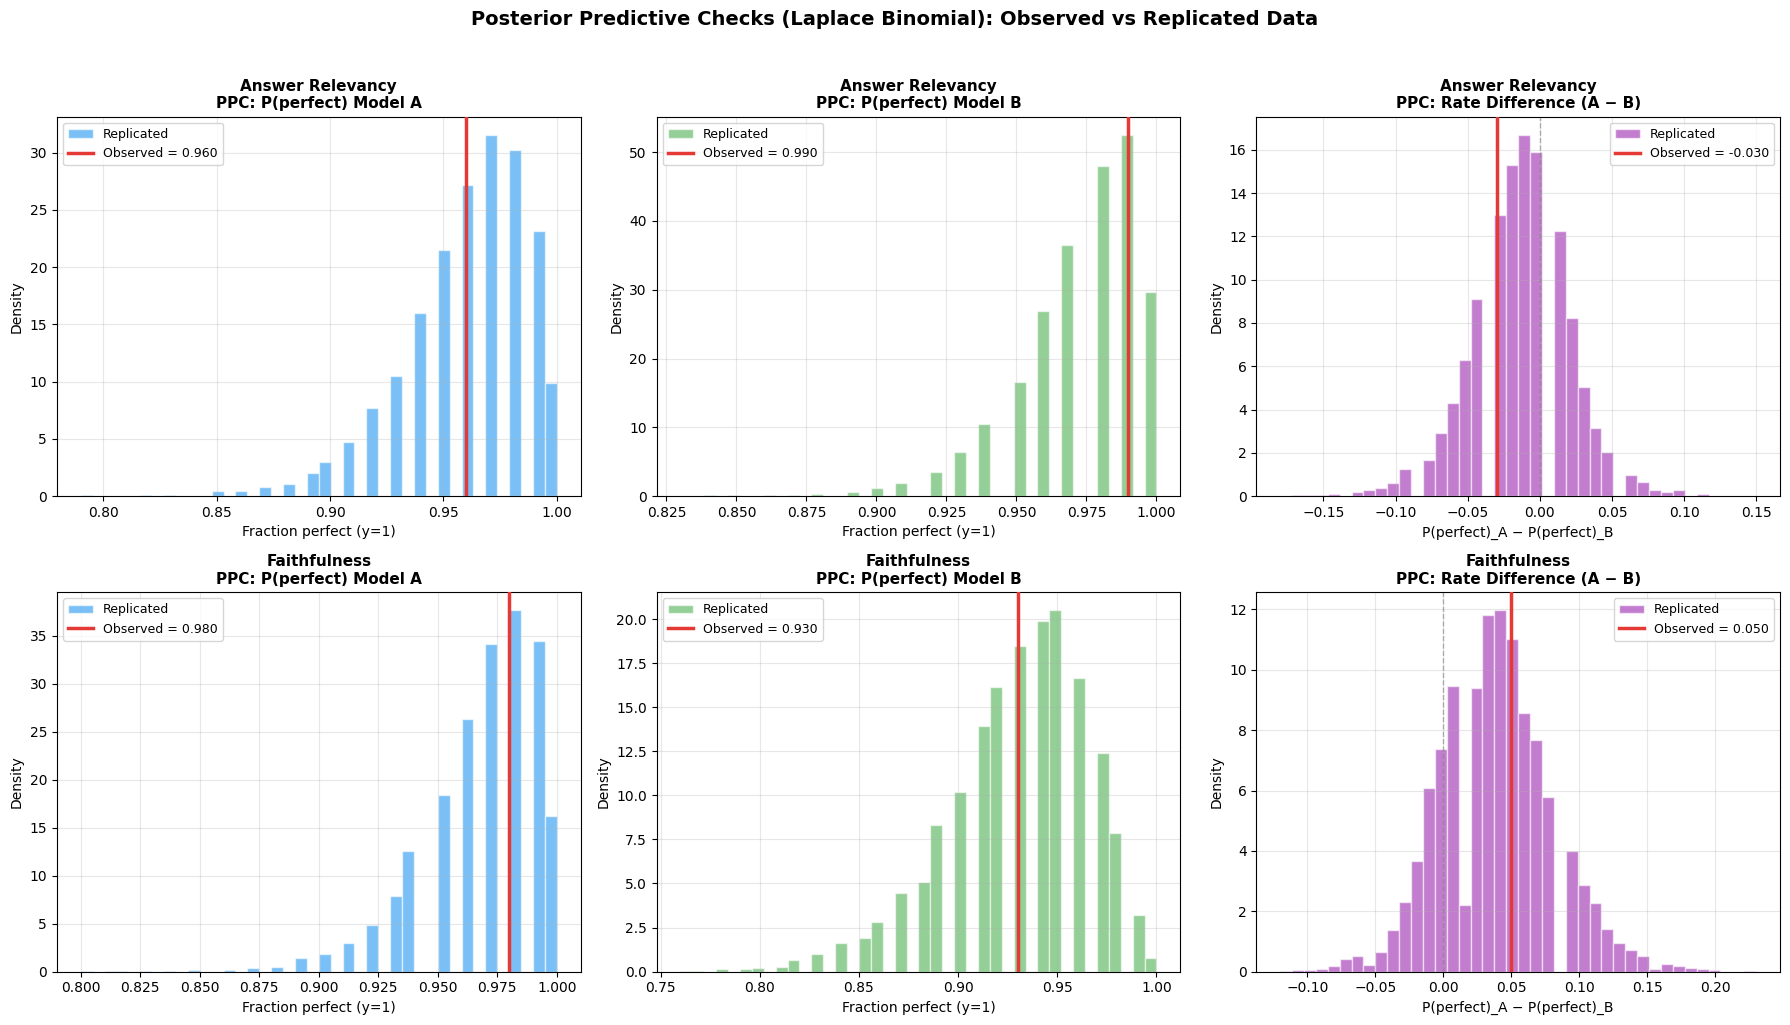

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(comparison_results), 3, figsize=(18, 5 * len(comparison_results)))
if len(comparison_results) == 1:
    axes = axes[np.newaxis, :]

rng_ppc = np.random.default_rng(42)

for row, (metric, res) in enumerate(comparison_results.items()):
    model = res['model']
    laplace = model.laplace
    mu_s = laplace['mu_samples']
    delta_s = laplace['delta_A_samples']
    y_A_obs = model.y_A_obs
    y_B_obs = model.y_B_obs
    n = len(y_A_obs)

    # PPC: simulate replicated data from Laplace posterior
    p_A_s = sigmoid(mu_s + delta_s)
    p_B_s = sigmoid(mu_s)
    y_A_rep = (rng_ppc.random((len(p_A_s), n)) < p_A_s[:, None]).astype(int)
    y_B_rep = (rng_ppc.random((len(p_B_s), n)) < p_B_s[:, None]).astype(int)

    # --- Column 1: Fraction of perfect scores (y=1) for Model A ---
    ax = axes[row, 0]
    frac_A_rep = y_A_rep.mean(axis=1)
    frac_A_obs = y_A_obs.mean()
    ax.hist(frac_A_rep, bins=40, density=True, color='#2196F3', alpha=0.6, edgecolor='white', label='Replicated')
    ax.axvline(frac_A_obs, color='#E53935', linewidth=2.5, label=f'Observed = {frac_A_obs:.3f}', zorder=10)
    ax.set_xlabel('Fraction perfect (y=1)')
    ax.set_ylabel('Density')
    ax.set_title(f'{metric}\nPPC: P(perfect) Model A', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # --- Column 2: Fraction of perfect scores (y=1) for Model B ---
    ax = axes[row, 1]
    frac_B_rep = y_B_rep.mean(axis=1)
    frac_B_obs = y_B_obs.mean()
    ax.hist(frac_B_rep, bins=40, density=True, color='#4CAF50', alpha=0.6, edgecolor='white', label='Replicated')
    ax.axvline(frac_B_obs, color='#E53935', linewidth=2.5, label=f'Observed = {frac_B_obs:.3f}', zorder=10)
    ax.set_xlabel('Fraction perfect (y=1)')
    ax.set_ylabel('Density')
    ax.set_title(f'{metric}\nPPC: P(perfect) Model B', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # --- Column 3: Difference in rates ---
    ax = axes[row, 2]
    diff_rep = frac_A_rep - frac_B_rep
    diff_obs = frac_A_obs - frac_B_obs
    ax.hist(diff_rep, bins=40, density=True, color='#9C27B0', alpha=0.6, edgecolor='white', label='Replicated')
    ax.axvline(diff_obs, color='#E53935', linewidth=2.5, label=f'Observed = {diff_obs:.3f}', zorder=10)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlabel('P(perfect)_A − P(perfect)_B')
    ax.set_ylabel('Density')
    ax.set_title(f'{metric}\nPPC: Rate Difference (A − B)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Posterior Predictive Checks (Laplace Binomial): Observed vs Replicated Data',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig("../../docs/ppc_binomial_model.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [12]:
# Posterior predictive p-values — Binomial model (Laplace)
print("Posterior Predictive p-values (two-sided) — Binomial Model (Laplace)")
print("=" * 80)
print(f"{'Metric':<20} {'Statistic':<20} {'Observed':>10} {'p-value':>10} {'Status':>10}")
print("=" * 80)

for metric, res in comparison_results.items():
    model = res['model']
    ppc = model.ppc_pvalues(seed=42)

    for stat_name, vals in ppc.items():
        print(f"{metric:<20} {stat_name:<20} {vals.observed:>10.4f} {vals.p_value:>10.3f} {vals.status:>10}")

print("=" * 80)
print("\np-value < 0.05 → observed statistic is extreme under the model (potential misfit)")
print("p-value > 0.05 → model reproduces this aspect of the data adequately")
print("\nn_disagree = number of items where y_A ≠ y_B (concordance check)")

Posterior Predictive p-values (two-sided) — Binomial Model (Laplace)
Metric               Statistic              Observed    p-value     Status
Answer Relevancy     mean(y_A)                0.9600      1.000         OK
Answer Relevancy     mean(y_B)                0.9900      0.699         OK
Answer Relevancy     mean(y_A-y_B)           -0.0300      0.662         OK
Answer Relevancy     std(y_A-y_B)             0.2216      0.738         OK
Answer Relevancy     n_disagree               5.0000      0.884         OK
Faithfulness         mean(y_A)                0.9800      0.882         OK
Faithfulness         mean(y_B)                0.9300      1.000         OK
Faithfulness         mean(y_A-y_B)            0.0500      0.820         OK
Faithfulness         std(y_A-y_B)             0.2958      0.897         OK
Faithfulness         n_disagree               9.0000      0.984         OK

p-value < 0.05 → observed statistic is extreme under the model (potential misfit)
p-value > 0.05 → model 

## Bayesian Hypothesis Test: $H_0: \delta_A = 0$ vs $H_1: \delta_A \neq 0$

### The measure-theoretic subtlety

Under a purely continuous prior on $\delta_A$, the singleton $\{\delta_A = 0\}$ has **Lebesgue measure zero** — it can never receive positive posterior probability regardless of the data. To make the point null $H_0$ a proper hypothesis we use a **spike-and-slab** mixed prior:

$$
\pi(\delta_A) = \pi_0 \,\delta_{\{0\}}(\delta_A) \;+\; (1-\pi_0)\, g(\delta_A)
$$

- **Spike**: discrete prior mass $\pi_0 = P(H_0)$ on the point $\delta_A = 0$
- **Slab**: continuous density $g(\delta_A) = N(0, \sigma_s^2)$ on $\mathbb{R}\setminus\{0\}$

### Bayes Factor via the Savage-Dickey density ratio

$$
BF_{01} = \frac{p(\delta_A = 0 \mid D,\, H_1)}{g(0)} = \frac{\text{posterior density at 0 (KDE)}}{\text{slab prior density at 0}}
$$

With a $N(0, \sigma_s^2)$ slab: $g(0) = \frac{1}{\sigma_s\sqrt{2\pi}}$.

**Prior consistency:** The Binomial model uses the same fixed prior $\delta_A \sim N(0, \sigma_s^2)$ as before, so the Savage-Dickey ratio is exactly consistent.

### Interpretation scale (Jeffreys)

| $BF_{10}$ | Evidence against $H_0$ |
|-----------|----------------------|
| < 1 | Supports $H_0$ |
| 1 -- 3 | Anecdotal |
| 3 -- 10 | Moderate |
| 10 -- 30 | Strong |
| 30 -- 100 | Very strong |
| > 100 | Decisive |

In [13]:
print("Savage-Dickey Bayes Factor: H0 (δ_A = 0) vs H1 (δ_A ≠ 0) — Binomial Model")
print("=" * 70)

bf_results = {}
for metric, res in comparison_results.items():
    model = res['model']
    bf = model.savage_dickey_test()
    bf_results[metric] = bf

    print(f"\n{metric}:")
    print(f"  Prior  density at δ=0: {bf.prior_density_at_0:.6f}")
    print(f"  Post.  density at δ=0: {bf.posterior_density_at_0:.2e}")
    print(f"  BF_01 (for H0):        {_format_bf(bf.BF_01)}")
    print(f"  BF_10 (against H0):    {_format_bf(bf.BF_10)}")
    print(f"  log₁₀(BF_10):          {np.log10(bf.BF_10):.1f}")
    print(f"  → {bf.interpretation}")
    print(f"  → Decision: {bf.decision}")

print("\n" + "=" * 70)
print(f"{'Metric':<25} {'log₁₀(BF₁₀)':>12} {'Decision':>20}   {'Interpretation'}")
print("=" * 70)
for m, bf in bf_results.items():
    print(f"{m:<25} {np.log10(bf.BF_10):>12.1f} {bf.decision:>20}   {bf.interpretation}")
print("=" * 70)

Savage-Dickey Bayes Factor: H0 (δ_A = 0) vs H1 (δ_A ≠ 0) — Binomial Model

Answer Relevancy:
  Prior  density at δ=0: 0.398942
  Post.  density at δ=0: 4.85e-01
  BF_01 (for H0):        1.22
  BF_10 (against H0):    0.82
  log₁₀(BF_10):          -0.1
  → Anecdotal evidence for H0
  → Decision: Fail to reject H0

Faithfulness:
  Prior  density at δ=0: 0.398942
  Post.  density at δ=0: 2.15e-01
  BF_01 (for H0):        0.54
  BF_10 (against H0):    1.86
  log₁₀(BF_10):          0.3
  → Anecdotal evidence against H0
  → Decision: Fail to reject H0

Metric                     log₁₀(BF₁₀)             Decision   Interpretation
Answer Relevancy                  -0.1    Fail to reject H0   Anecdotal evidence for H0
Faithfulness                       0.3    Fail to reject H0   Anecdotal evidence against H0


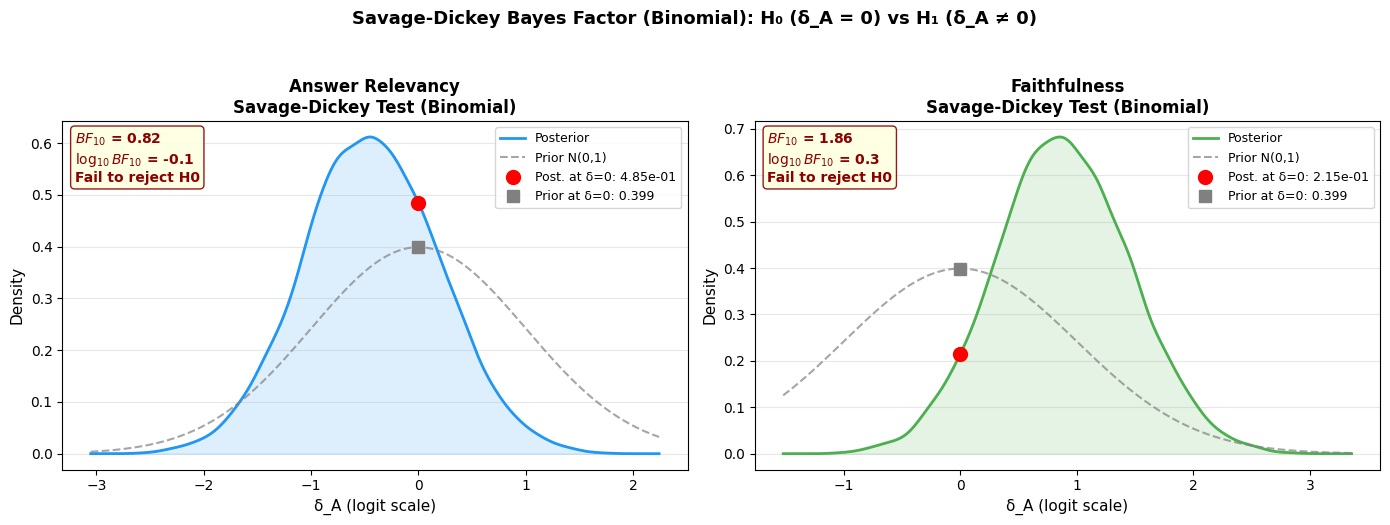

In [14]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm

fig, axes = plt.subplots(1, len(bf_results), figsize=(7 * len(bf_results), 5), squeeze=False)
axes = axes[0]

colors_map = {'Answer Relevancy': '#2196F3', 'Faithfulness': '#4CAF50'}

for ax, (metric, res) in zip(axes, comparison_results.items()):
    model = res['model']
    samples = model.delta_A_samples
    bf = bf_results[metric]

    kde = gaussian_kde(samples)
    x_grid = np.linspace(samples.min() - 0.5, samples.max() + 0.5, 500)
    density = kde(x_grid)

    col = colors_map.get(metric, '#2196F3')

    ax.plot(x_grid, density, color=col, linewidth=2, label='Posterior')
    ax.fill_between(x_grid, density, alpha=0.15, color=col)

    prior_density = norm.pdf(x_grid, 0, 1.0)
    ax.plot(x_grid, prior_density, color='gray', linewidth=1.5, linestyle='--', alpha=0.7, label='Prior N(0,1)')

    ax.plot(0, bf.posterior_density_at_0, 'o', color='red', markersize=10, zorder=5,
            label=f'Post. at δ=0: {bf.posterior_density_at_0:.2e}')
    ax.plot(0, bf.prior_density_at_0, 's', color='gray', markersize=8, zorder=5,
            label=f'Prior at δ=0: {bf.prior_density_at_0:.3f}')

    bf10_label = _format_bf(bf.BF_10)
    log10_bf = np.log10(bf.BF_10)
    ax.text(
        0.02, 0.97,
        f'$BF_{{10}}$ = {bf10_label}\n$\\log_{{10}}BF_{{10}}$ = {log10_bf:.1f}\n{bf.decision}',
        fontsize=10, fontweight='bold', color='darkred',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='darkred', alpha=0.9),
    )

    ax.set_xlabel('δ_A (logit scale)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{metric}\nSavage-Dickey Test (Binomial)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Savage-Dickey Bayes Factor (Binomial): H₀ (δ_A = 0) vs H₁ (δ_A ≠ 0)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
fig.savefig("../../docs/savage_dickey_bf_binomial.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### From Bayes Factor to Posterior Probability of $H_0$

$$
P(H_0 \mid D) = \frac{\pi_0 \cdot BF_{01}}{\pi_0 \cdot BF_{01} + (1 - \pi_0)}
$$

With the default agnostic prior $\pi_0 = 0.5$: $P(H_0 \mid D) = BF_{01}/(1 + BF_{01})$.

In [15]:
prior_H0 = 0.5

print(f"Prior: P(H0) = {prior_H0}, P(H1) = {1 - prior_H0}")
print("=" * 85)
print(f"{'Metric':<25} {'log₁₀BF₁₀':>10} {'P(H0|D)':>10} {'P(H1|D)':>10} {'Decision':>15}")
print("=" * 85)

for metric, bf in bf_results.items():
    post = PairedBayesPropTest.posterior_probability_H0(bf.BF_01, prior_H0=prior_H0)

    decision = "Reject H0" if post.p_H1 > 0.95 else (
        "Reject H0 (weak)" if post.p_H1 > 0.75 else "Fail to reject H0"
    )

    print(
        f"{metric:<25} "
        f"{np.log10(bf.BF_10):>10.1f} "
        f"{post.p_H0:>10.2e} "
        f"{post.p_H1:>10.6f} "
        f"{decision:>15}"
    )

print("=" * 85)
print()
print("Interpretation:")
print("  P(H0|data) → probability that δ_A = 0  (models are equivalent)")
print("  P(H1|data) → probability that δ_A ≠ 0  (models differ)")
print("  Decision: Reject H0 if P(H1|data) > 0.95")

Prior: P(H0) = 0.5, P(H1) = 0.5
Metric                     log₁₀BF₁₀    P(H0|D)    P(H1|D)        Decision
Answer Relevancy                -0.1   5.49e-01   0.451429 Fail to reject H0
Faithfulness                     0.3   3.50e-01   0.650000 Fail to reject H0

Interpretation:
  P(H0|data) → probability that δ_A = 0  (models are equivalent)
  P(H1|data) → probability that δ_A ≠ 0  (models differ)
  Decision: Reject H0 if P(H1|data) > 0.95


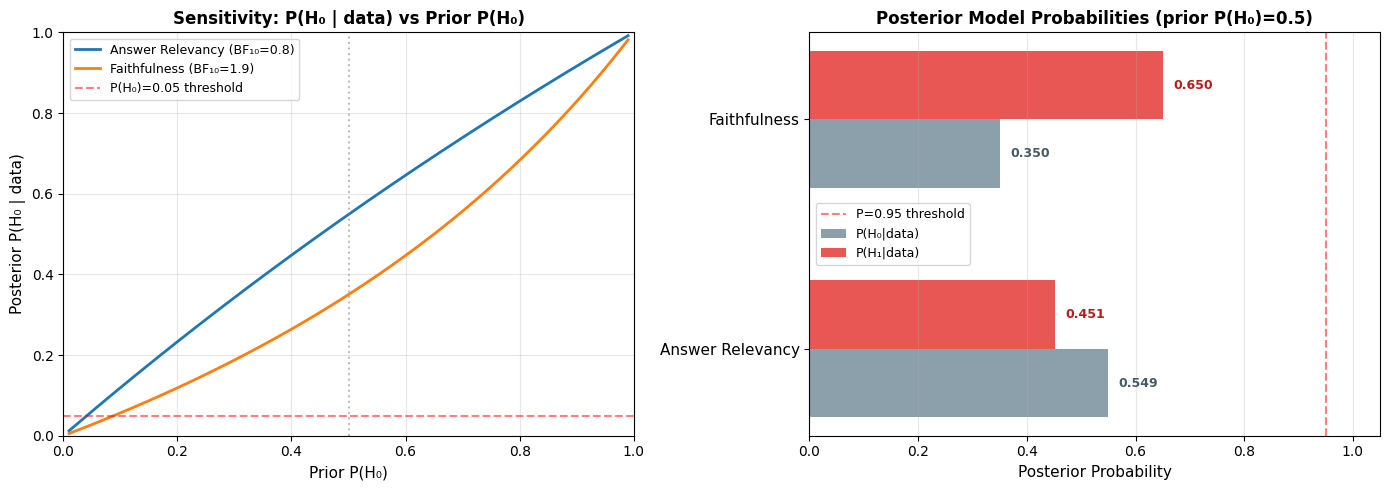

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
prior_grid = np.linspace(0.01, 0.99, 200)

for metric, bf in bf_results.items():
    p_h0_grid = [PairedBayesPropTest.posterior_probability_H0(bf.BF_01, p).p_H0 for p in prior_grid]
    bf10 = bf.BF_10
    bf_label = f"log₁₀BF₁₀={np.log10(bf10):.0f}" if bf10 > 1e4 else f"BF₁₀={bf10:.1f}"
    ax.plot(prior_grid, p_h0_grid, linewidth=2, label=f"{metric} ({bf_label})")

ax.axhline(0.05, color='red', linestyle='--', alpha=0.5, label='P(H₀)=0.05 threshold')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Prior P(H₀)', fontsize=11)
ax.set_ylabel('Posterior P(H₀ | data)', fontsize=11)
ax.set_title('Sensitivity: P(H₀ | data) vs Prior P(H₀)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax2 = axes[1]
metrics_list = list(bf_results.keys())
p_h0_vals = []
p_h1_vals = []
for m in metrics_list:
    post = PairedBayesPropTest.posterior_probability_H0(bf_results[m].BF_01, prior_H0=0.5)
    p_h0_vals.append(post.p_H0)
    p_h1_vals.append(post.p_H1)

y_pos = np.arange(len(metrics_list))
ax2.barh(y_pos - 0.15, p_h0_vals, height=0.3, color='#78909C', alpha=0.85, label='P(H₀|data)')
ax2.barh(y_pos + 0.15, p_h1_vals, height=0.3, color='#E53935', alpha=0.85, label='P(H₁|data)')

ax2.axvline(0.95, color='red', linestyle='--', alpha=0.5, label='P=0.95 threshold')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(metrics_list, fontsize=11)
ax2.set_xlabel('Posterior Probability', fontsize=11)
ax2.set_title(f'Posterior Model Probabilities (prior P(H₀)={prior_H0})', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 1.05)
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)

for i, (h0, h1) in enumerate(zip(p_h0_vals, p_h1_vals)):
    ax2.text(h0 + 0.02, i - 0.15, f'{h0:.3f}', va='center', fontsize=9, fontweight='bold', color='#455A64')
    ax2.text(h1 + 0.02, i + 0.15, f'{h1:.3f}', va='center', fontsize=9, fontweight='bold', color='#B71C1C')

plt.tight_layout()
fig.savefig("../../docs/sensitivity_prior_h0_binomial.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### Sensitivity to the slab width $\sigma_s$

The Bayes Factor depends on the choice of slab width $\sigma_s$ (Jeffreys-Lindley effect). We assess robustness by sweeping $\sigma_s$ over a range of plausible values.

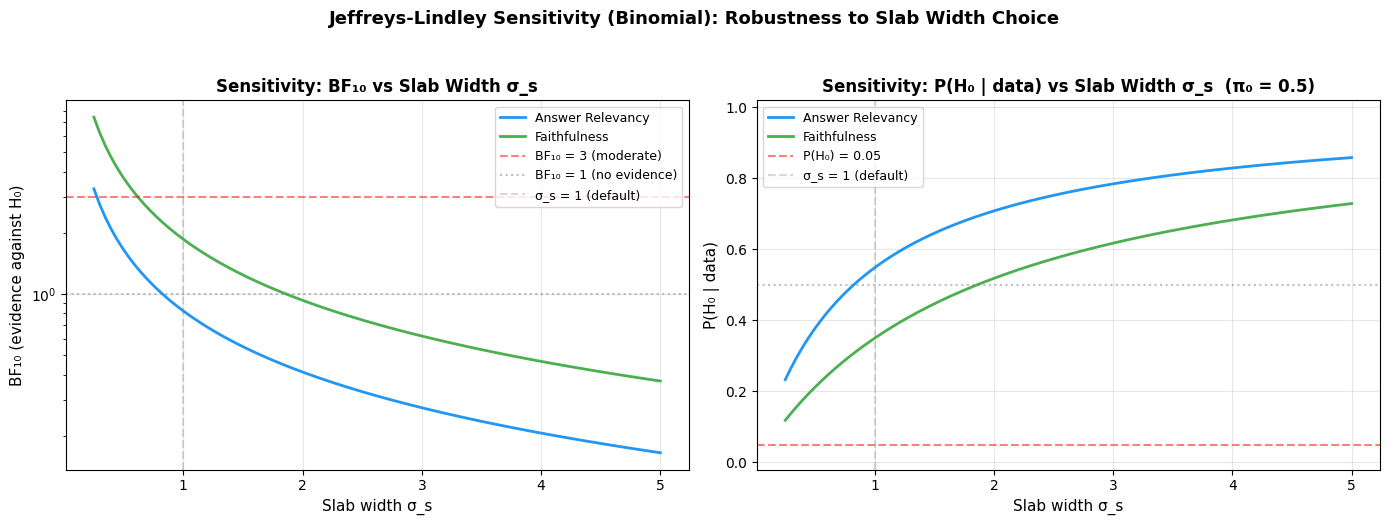

In [17]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm

sigma_grid = np.linspace(0.25, 5.0, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {'Answer Relevancy': '#2196F3', 'Faithfulness': '#4CAF50'}

ax = axes[0]
for metric, res in comparison_results.items():
    model = res['model']
    samples = model.delta_A_samples
    kde = gaussian_kde(samples)
    post_at_0 = float(kde(0.0)[0])

    bf10_vals = [norm.pdf(0, 0, s) / post_at_0 for s in sigma_grid]
    col = colors_map.get(metric, '#2196F3')
    ax.plot(sigma_grid, bf10_vals, linewidth=2, color=col, label=metric)

ax.axhline(3, color='red', linestyle='--', alpha=0.5, label='BF₁₀ = 3 (moderate)')
ax.axhline(1, color='gray', linestyle=':', alpha=0.5, label='BF₁₀ = 1 (no evidence)')
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.3, label='σ_s = 1 (default)')
ax.set_xlabel('Slab width σ_s', fontsize=11)
ax.set_ylabel('BF₁₀ (evidence against H₀)', fontsize=11)
ax.set_title('Sensitivity: BF₁₀ vs Slab Width σ_s', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
for metric, res in comparison_results.items():
    model = res['model']
    samples = model.delta_A_samples
    kde = gaussian_kde(samples)
    post_at_0 = float(kde(0.0)[0])

    p_h0_vals = []
    for s in sigma_grid:
        prior_at_0 = norm.pdf(0, 0, s)
        bf01 = post_at_0 / prior_at_0
        p_h0 = bf01 / (1 + bf01)
        p_h0_vals.append(p_h0)

    col = colors_map.get(metric, '#2196F3')
    ax2.plot(sigma_grid, p_h0_vals, linewidth=2, color=col, label=metric)

ax2.axhline(0.05, color='red', linestyle='--', alpha=0.5, label='P(H₀) = 0.05')
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax2.axvline(1.0, color='gray', linestyle='--', alpha=0.3, label='σ_s = 1 (default)')
ax2.set_xlabel('Slab width σ_s', fontsize=11)
ax2.set_ylabel('P(H₀ | data)', fontsize=11)
ax2.set_title('Sensitivity: P(H₀ | data) vs Slab Width σ_s  (π₀ = 0.5)', fontsize=12, fontweight='bold')
ax2.set_ylim(-0.02, 1.02)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle('Jeffreys-Lindley Sensitivity (Binomial): Robustness to Slab Width Choice',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
fig.savefig("../../docs/sensitivity_slab_width_binomial.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Nonparametric Comparison: McNemar's Test

For paired binary data, the appropriate nonparametric test is **McNemar's test** (not Wilcoxon, which is for continuous paired differences). McNemar's test compares the discordant pairs:

- $b$ = items where A is perfect and B is not ($y_A = 1, y_B = 0$)
- $c$ = items where B is perfect and A is not ($y_A = 0, y_B = 1$)

$$
\chi^2 = \frac{(b - c)^2}{b + c}
$$

Under $H_0$ (no difference): $\chi^2 \sim \chi^2_1$.

We also include Wilcoxon on the raw (continuous) scores as a secondary check.

In [18]:
from scipy.stats import wilcoxon, binomtest
import math
import numpy as np
import matplotlib.pyplot as plt

print("McNemar's Test (paired binary) and Wilcoxon (paired continuous): Model A vs Model B")
print("=" * 85)

for metric, res in comparison_results.items():
    model = res['model']
    y_A = model.y_A_obs
    y_B = model.y_B_obs
    s_A = res['s_A_raw']
    s_B = res['s_B_raw']

    # McNemar's test on binarized data
    b = np.sum((y_A == 1) & (y_B == 0))  # A perfect, B not
    c = np.sum((y_A == 0) & (y_B == 1))  # B perfect, A not
    n_concordant = np.sum(y_A == y_B)
    n_discordant = b + c

    print(f"\n{metric}:")
    print(f"  Concordant pairs: {n_concordant}  (both perfect: {np.sum((y_A==1)&(y_B==1))}, both imperfect: {np.sum((y_A==0)&(y_B==0))})")
    print(f"  Discordant pairs: {n_discordant}  (A>B: {b}, B>A: {c})")

    if n_discordant == 0:
        print(f"  McNemar: No discordant pairs — cannot test")
    else:
        # Exact binomial test (preferred for small n_discordant)
        p_mcnemar = 2 * min(
            float(sum(
                math.comb(n_discordant, k) * 0.5**n_discordant
                for k in range(min(b, c) + 1)
            )),
            1.0,
        )
        # Also compute chi-squared version
        chi2_stat = (b - c) ** 2 / (b + c)
        from scipy.stats import chi2
        p_chi2 = 1 - chi2.cdf(chi2_stat, df=1)

        decision = "Reject H0" if p_mcnemar < 0.05 else "Fail to reject"
        print(f"  McNemar exact p-value:  {p_mcnemar:.4f}  → {decision}")
        print(f"  McNemar χ² = {chi2_stat:.2f}, p = {p_chi2:.4f}")

    # Wilcoxon on raw continuous scores
    diff = s_A - s_B
    if np.all(diff == 0):
        print(f"  Wilcoxon: All tied — cannot test")
    else:
        stat, p_val = wilcoxon(diff, alternative='two-sided')
        decision_w = "Reject H0" if p_val < 0.05 else "Fail to reject"
        print(f"  Wilcoxon (raw scores):  stat={stat:.1f}, p={p_val:.4f}  → {decision_w}")

print("\n" + "=" * 85)
print("McNemar tests whether the rate of perfect scores differs between models (binary).")
print("Wilcoxon tests whether the continuous score distributions differ (raw scores).")

McNemar's Test (paired binary) and Wilcoxon (paired continuous): Model A vs Model B

Answer Relevancy:
  Concordant pairs: 95  (both perfect: 95, both imperfect: 0)
  Discordant pairs: 5  (A>B: 1, B>A: 4)
  McNemar exact p-value:  0.3750  → Fail to reject
  McNemar χ² = 1.80, p = 0.1797
  Wilcoxon (raw scores):  stat=37.5, p=0.3458  → Fail to reject

Faithfulness:
  Concordant pairs: 91  (both perfect: 91, both imperfect: 0)
  Discordant pairs: 9  (A>B: 7, B>A: 2)
  McNemar exact p-value:  0.1797  → Fail to reject
  McNemar χ² = 2.78, p = 0.0956
  Wilcoxon (raw scores):  stat=23.0, p=0.1145  → Fail to reject

McNemar tests whether the rate of perfect scores differs between models (binary).
Wilcoxon tests whether the continuous score distributions differ (raw scores).


## Summary: Beta vs Binomial vs Wilcoxon

| Method | Data type | Handles boundary spikes? | Distributional assumptions | Key question |
|--------|-----------|--------------------------|---------------------------|-------------|
| **Beta regression** (v1) | Continuous (0,1) | No — PPC fails, BF unreliable | Beta likelihood | What is the mean score difference? |
| **Binomial logistic** (this notebook) | Binary {0,1} | Yes — boundary *is* the signal | Bernoulli + logistic link | Does A achieve perfect scores more often? |
| **McNemar** | Binary {0,1} | N/A (nonparametric) | None | Are discordant pairs symmetric? |
| **Wilcoxon** | Continuous ranks | N/A (nonparametric) | Symmetry of differences | Do continuous scores differ? |

If the Binomial PPC p-values pass (all OK) and the Savage-Dickey BF agrees with McNemar/Wilcoxon, the model is well-specified and the Bayesian results are trustworthy.

## Bayes Factor Design Analysis (BFDA) — Sample Size Planning (Paired Design)

In frequentist testing we compute the **power** — the probability of rejecting H₀ given a true effect.
The Bayesian analog is **Bayes Factor Design Analysis**: for a hypothesised true effect
$\Delta = \theta_A - \theta_B$, simulate many paired datasets at each sample size and estimate the
probability of obtaining *decisive* evidence (e.g. $BF_{10} > 3$).

$$
\text{Bayesian Power}(n) = P\!\left(BF_{10} > \text{threshold} \;\middle|\; \theta_A, \theta_B, n\right)
$$

For the **paired** design we use the Pólya-Gamma logistic model + Savage-Dickey BF.
This is more expensive per simulation (MCMC for each dataset), so we use fewer
simulations during exploration and increase for final reporting.

### References

1. **Schönbrodt, F. D. & Wagenmakers, E.-J.** (2018). Bayes factor design analysis: Planning for compelling evidence. *Psychonomic Bulletin & Review*, 25(1), 128–142.
2. **Stefan, A. M., Gronau, Q. F., Schönbrodt, F. D., & Wagenmakers, E.-J.** (2019). A tutorial on Bayes Factor Design Analysis using an informed prior. *Behavior Research Methods*, 51(3), 1042–1058.
3. **Kruschke, J. K.** (2013). Bayesian estimation supersedes the t test. *Journal of Experimental Psychology: General*, 142(2), 573–603.
4. **Weiss, R.** (1997). Bayesian sample size calculations for hypothesis testing. *Journal of the Royal Statistical Society: Series D*, 46(2), 185–191.

In [19]:
from bayesAB.utils.utils import (
    bfda_power_curve_paired,
    bfda_power_curve_ph0,
    find_n_for_power,
    plot_bfda_power,
    plot_bfda_sensitivity,
)

# ── Use observed rates as plug-in estimates for the true effect ────────
# Pull from the first metric's model (Faithfulness typically)
#metric_for_bfda = "Answer Relevancy"
metric_for_bfda = "Faithfulness"

_model = comparison_results[metric_for_bfda]['model']
theta_A_hat = _model.y_A_obs.mean()
theta_B_hat = _model.y_B_obs.mean()

print(f"Assumed true rates (from observed data, metric: {metric_for_bfda}):")
print(f"  θ_A = {theta_A_hat:.3f}  (pass rate, gemini-2.5-flash)")
print(f"  θ_B = {theta_B_hat:.3f}  (pass rate, gemini-2.0-flash)")
print(f"  True Δ = {theta_A_hat - theta_B_hat:.3f} (effect size)")
print()

# ── Compute BFDA power curve (paired PG model) ───────────────────────
sample_sizes = [20, 30, 50, 75, 100, 150, 200, 300, 500]

power_curve_paired = bfda_power_curve_paired(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    bf_threshold=3.0,
    n_sim=200,       # fewer sims (MCMC per dataset)
    n_iter=1000,
    burn_in=300,
    n_chains=2,
    seed=42,
)

print(f"{'n (per group)':<15} {'P(BF₁₀ > 3)':>12}")
print("-" * 28)
for n, p in power_curve_paired.items():
    print(f"{n:<15} {p:>12.3f}")

n_80 = find_n_for_power(power_curve_paired, 0.80)
print(f"\n→ Estimated n for 80% power: ≈ {n_80:.0f}" if n_80 else "\n→ n for 80% power: > 500")

Assumed true rates (from observed data, metric: Faithfulness):
  θ_A = 0.980  (pass rate, gemini-2.5-flash)
  θ_B = 0.930  (pass rate, gemini-2.0-flash)
  True Δ = 0.050 (effect size)

n (per group)    P(BF₁₀ > 3)
----------------------------
20                     0.010
30                     0.020
50                     0.145
75                     0.245
100                    0.370
150                    0.430
200                    0.660
300                    0.795
500                    0.965

→ Estimated n for 80% power: ≈ 306


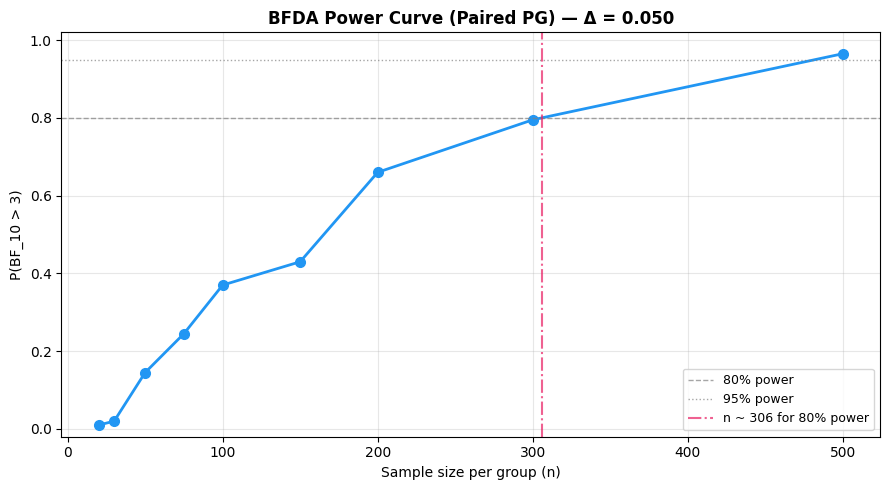

In [20]:
plot_bfda_power(
    power_curve_paired, theta_A_hat, theta_B_hat,
    title=f"BFDA Power Curve (Paired PG) — Δ = {theta_A_hat - theta_B_hat:.3f}"
)
plt.show()

In [ ]:
plot_bfda_sensitivity(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    thresholds=[3.0, 6.0, 10.0],
    n_sim=200,
    seed=42,
    design="paired",
    title="BFDA Sensitivity (Paired PG) — Multiple BF₁₀ Thresholds",
)
plt.show()

### BFDA via posterior probability of H₀ (Paired)

Since $P(H_0 \mid \text{data})$ is a monotonic transformation of $BF_{01}$:

$$
P(H_0 \mid \text{data}) = \frac{BF_{01} \cdot \pi_0}{BF_{01} \cdot \pi_0 + (1 - \pi_0)}
$$

we can equivalently define "decisive evidence" as $P(H_0) < \alpha$ for some threshold $\alpha$.
For equal prior odds ($\pi_0 = 0.5$), the correspondence is:

| $BF_{10}$ threshold | $P(H_0)$ threshold |
|:---:|:---:|
| 3 | 0.250 |
| 6 | 0.143 |
| 10 | 0.091 |
| 20 | 0.048 |

KeyboardInterrupt: 

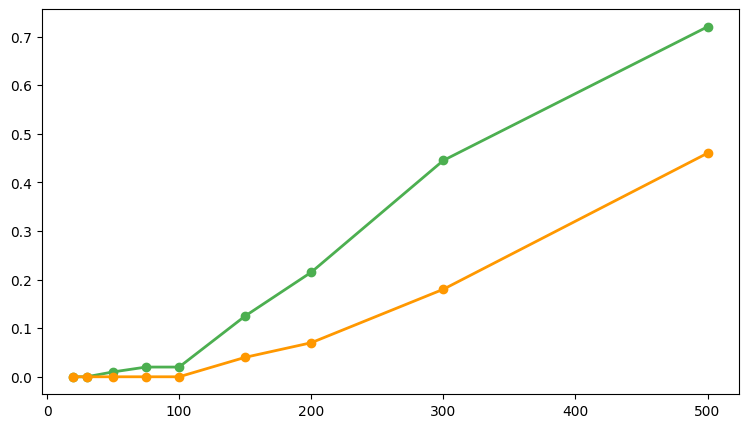

In [ ]:
# ── Power curves for different P(H₀) thresholds (paired design) ──────
fig, ax = plt.subplots(figsize=(9, 5))

ph0_thresholds = [0.25, 0.10, 0.05]
colors_ph0 = ["#4CAF50", "#FF9800", "#E91E63"]

for thresh, col in zip(ph0_thresholds, colors_ph0):
    curve = bfda_power_curve_ph0(
        theta_A_true=theta_A_hat,
        theta_B_true=theta_B_hat,
        sample_sizes=sample_sizes,
        ph0_threshold=thresh,
        n_sim=200,
        seed=42,
        design="paired",
    )
    ax.plot(list(curve.keys()), list(curve.values()), "o-",
            color=col, linewidth=2, markersize=6, label=f"P(H₀) < {thresh}")

ax.axhline(0.80, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Sample size per group (n)")
ax.set_ylabel("P(P(H₀|data) < threshold)")
ax.set_title(
    f"BFDA via P(H₀) — Paired Design — Δ = {theta_A_hat - theta_B_hat:.3f} "
    f"(π₀ = 0.5)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Print equivalence table ───────────────────────────────────────────
print(f"\n{'P(H₀) thresh':<15} {'≡ BF₁₀ >':<12} {'n for 80% power':>16}")
print("-" * 45)
for thresh in ph0_thresholds:
    bf10_equiv = (1 - thresh) / thresh
    curve = bfda_power_curve_ph0(
        theta_A_true=theta_A_hat,
        theta_B_true=theta_B_hat,
        sample_sizes=sample_sizes,
        ph0_threshold=thresh,
        n_sim=200,
        seed=42,
        design="paired",
    )
    n_80 = find_n_for_power(curve, 0.80)
    n_str = f"≈ {n_80:.0f}" if n_80 is not None else "> 500"
    print(f"{thresh:<15.2f} {bf10_equiv:<12.1f} {n_str:>16}")